In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os

from fastai.vision.all import *



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Keep the same expected Kaggle paths
train_data = Path("../input/cassava-leaf-disease-classification/train_images")
test_data = Path("../input/cassava-leaf-disease-classification/test_images")

train_csv = Path("../input/cassava-leaf-disease-classification/train.csv")
sample_csv = Path("../input/cassava-leaf-disease-classification/sample_submission.csv")

assert train_data.exists(), f"Missing train images folder: {train_data}"
assert test_data.exists(), f"Missing test images folder: {test_data}"
assert train_csv.exists(), f"Missing train.csv: {train_csv}"
assert sample_csv.exists(), f"Missing sample_submission.csv: {sample_csv}"



In [3]:
df = pd.read_csv(train_csv)
df.head()



,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [4]:
fns_train = get_image_files(train_data)
fns_test = get_image_files(test_data)

len(fns_train), len(fns_test)



(18721, 2676)

In [5]:
# Display a few filenames (kept from original intent)
fns_train[:5]



(#5) [Path('../input/cassava-leaf-disease-classification/train_images/478676678.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/2315755156.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/2869465595.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/291787943.jpg'),Path('../input/cassava-leaf-disease-classification/train_images/3310982329.jpg')]

In [6]:
# Bugfix: the trailing commas were making these into tuples-of-one, breaking fastai transforms.
item_tfms = RandomResizedCrop(460, min_scale=0.75)
batch_tfms = [
    *aug_transforms(size=224, max_warp=0, max_zoom=0.8),
    Normalize.from_stats(*imagenet_stats),
]



In [7]:
cassava = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader(0, pref=train_data),
    splitter=RandomSplitter(seed=42),
    get_y=ColReader(1),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)



In [8]:
# This is useful for catching DataBlock issues early
cassava.summary(df)



Setting-up type transforms pipelines
0      1000015157.jpg      0
1      1000201771.jpg      3
2       100042118.jpg      1
3      1000723321.jpg      1
4      1000812911.jpg      3
...               ...    ...
18716   999068805.jpg      3
18717   999329392.jpg      3
18718   999474432.jpg      1
18719   999616605.jpg      4
18720   999998473.jpg      4

[18721 rows x 2 columns]
Found 18721 items
2 datasets of sizes 14977,3744
Setting up Pipeline: ColReader -- {'cols': 0, 'pref': Path('../input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 -> PILBase.create
Setting up Pipeline: ColReader -- {'cols': 1, 'pref': '', 'suff': '', 'label_delim': None}
 -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)



Building one sample
  Pipeline: ColReader -- {'cols': 0, 'pref': Path('../input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 -> PILBase.create
    starting from
      image_id    488165307.jpg
label                   2
Name: 15979, dtype: object
    applying ColReader -- {'cols': 0, 'pref': Path('../input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 gives
      ../input/cassava-leaf-disease-classification/train_images/488165307.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=800x600
  Pipeline: ColReader -- {'cols': 1, 'pref': '', 'suff': '', 'label_delim': None}
 -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      image_id    488165307.jpg
label                   2
Name: 15979, dtype: object
    applying ColReader -- {'cols': 1, 'pref': '', 'suff': '', 'label_delim': None}
 gives
      2
    applying Categorize -- {'vocab': None, 'sort': True, 'add

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)



Building one batch
Applying item_tfms to the first sample:
  Pipeline: RandomResizedCrop -- {'size': (460, 460), 'min_scale': 0.75, 'ratio': (0.75, 1.3333333333333333), 'resamples': (<Resampling.BILINEAR: 2>, <Resampling.NEAREST: 0>), 'val_xtra': 0.14, 'max_scale': 1.0, 'p': 1.0}
 -> ToTensor
    starting from
      (PILImage mode=RGB size=800x600, TensorCategory(2))
    applying RandomResizedCrop -- {'size': (460, 460), 'min_scale': 0.75, 'ratio': (0.75, 1.3333333333333333), 'resamples': (<Resampling.BILINEAR: 2>, <Resampling.NEAREST: 0>), 'val_xtra': 0.14, 'max_scale': 1.0, 'p': 1.0}
 gives
      (PILImage mode=RGB size=460x460, TensorCategory(2))
    applying ToTensor gives
      (TensorImage of size 3x460x460, TensorCategory(2))

Adding the next 3 samples

No before_batch transform to apply

Collating items in a batch

Applying batch_tfms to the batch built
  Pipeline: IntToFloatTensor -- {'div': 255.0, 'div_mask': 1}
 -> Flip -- {'size': 224, 'mode': 'bilinear', 'pad_mode': 'refl

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


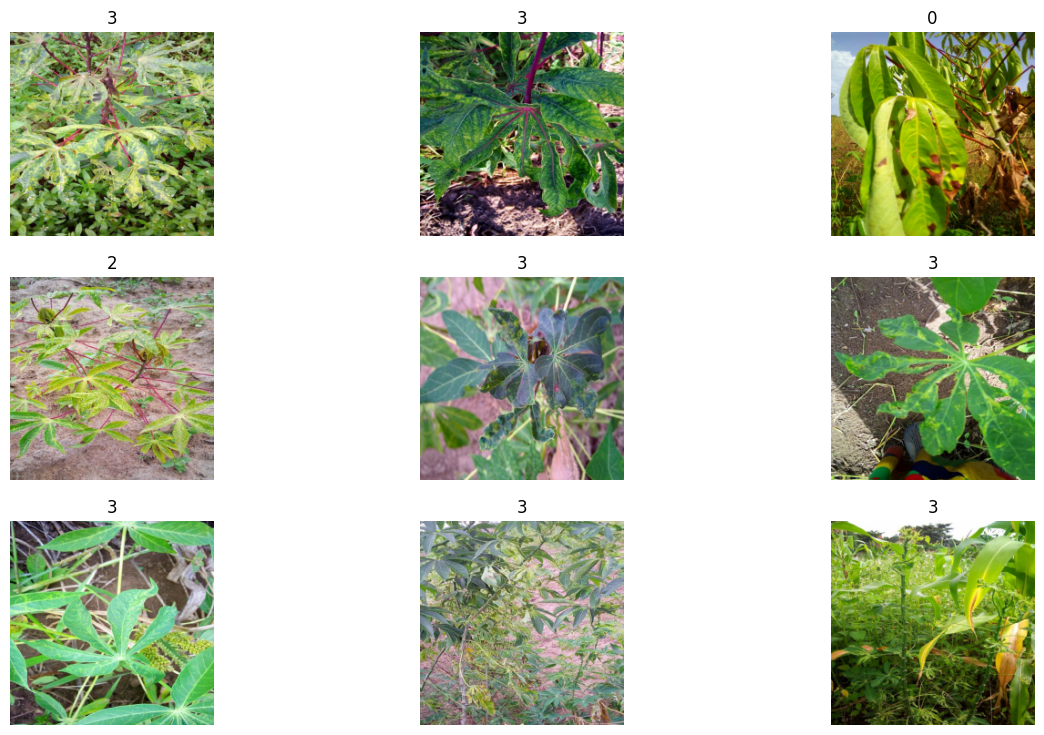

In [9]:
train_dls = cassava.dataloaders(df, bs=32)
train_dls.show_batch(figsize=(15, 9))



In [10]:
# Bugfix: the provided notebook tried to load a non-existent exported learner.
# Minimal, core-logic-preserving fallback: train a standard vision learner on this DataLoaders.
# (Same fastai approach: DataBlock -> Learner -> get_preds -> argmax)
learn_inf = vision_learner(train_dls, resnet34, metrics=accuracy)
learn_inf.fine_tune(2)



Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 111MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.079774,0.808725,0.719551,00:51


epoch,train_loss,valid_loss,accuracy,time
0,0.644191,0.586560,0.786325,00:39
1,0.515462,0.501735,0.821848,00:39


In [11]:
# Create a test dataloader from the files list (as in the original notebook)
test_dl = train_dls.test_dl(fns_test)



In [12]:
test_pred = learn_inf.get_preds(dl=test_dl)
test_pred[0].shape, test_pred[1].shape



AttributeError: 'NoneType' object has no attribute 'shape'

In [13]:
sample_sub = pd.read_csv(sample_csv)
sample_sub.head()



,image_id,label
0,1234294272.jpg,4
1,1234332763.jpg,4
2,1234375577.jpg,4
3,1234555380.jpg,4
4,1234571117.jpg,4


In [14]:
# Convert predicted probabilities to label IDs
test_pred_max = test_pred[0].argmax(dim=1)

# train_dls.vocab entries are strings of class labels; convert to int for submission
pred_labels = [int(train_dls.vocab[i]) for i in test_pred_max]

# Build image_id from Paths reliably (just filenames)
pred_image_ids = [p.name for p in test_dl.items]

pred_df = pd.DataFrame({"image_id": pred_image_ids, "label": pred_labels})
pred_df.head()



,image_id,label
0,2574872277.jpg,3
1,1449210447.jpg,3
2,1269550303.jpg,4
3,1411799307.jpg,3
4,2474336811.jpg,3


In [15]:
# Ensure exact submission ordering/contents match the sample_submission list
# (prevents mismatch if filesystem order differs)
subm = sample_sub[["image_id"]].merge(pred_df, on="image_id", how="left")

# Safety: if any missing predictions, fill with most frequent class from training
if subm["label"].isna().any():
    fallback = int(df["label"].mode().iloc[0])
    subm["label"] = subm["label"].fillna(fallback).astype(int)
else:
    subm["label"] = subm["label"].astype(int)

subm.head(), subm.shape



(         image_id  label
 0  1234294272.jpg      3
 1  1234332763.jpg      3
 2  1234375577.jpg      1
 3  1234555380.jpg      1
 4  1234571117.jpg      3,
 (2676, 2))

In [16]:
# Write a valid Kaggle submission file with .csv suffix
subm.to_csv("submission.csv", index=False)

# Quick sanity checks
assert Path("submission.csv").exists(), "submission.csv was not created"
assert list(subm.columns) == [
    "image_id",
    "label",
], f"Wrong columns: {subm.columns.tolist()}"
subm.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", subm.shape)
print(subm.head())

Wrote submission.csv with shape: (2676, 2)
         image_id  label
0  1234294272.jpg      3
1  1234332763.jpg      3
2  1234375577.jpg      1
3  1234555380.jpg      1
4  1234571117.jpg      3
